# Week 2 – Data Cleaning and Exploratory Data Analysis

## YUVAIntern Healthcare Data Science Internship 2026

### Project: Healthcare Data Science and Chemical Compound Analysis

This notebook presents the data cleaning, preprocessing, and exploratory data analysis performed on a synthetic dataset of chemical compounds.

The dataset contains molecular descriptors such as Molecular Weight, LogP, HBA, HBD, TPSA, and Rotatable Bonds, along with a Bioactivity classification.

The objective is to inspect the dataset, identify potential data-quality issues, summarize the molecular properties, and explore relationships and patterns within the data.

## Objective

The main objectives of this analysis are:

- Load and inspect the synthetic chemical-compound dataset.
- Understand the structure and characteristics of the dataset.
- Check for missing values and duplicate records.
- Examine descriptive statistics of molecular descriptors.
- Explore the distribution of important chemical properties.
- Analyze the distribution of bioactivity classes.
- Investigate relationships between molecular descriptors.
- Identify potential outliers using visual analysis.
- Generate insights that can support subsequent predictive modeling.

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Display more columns when viewing DataFrames
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset Loading

The dataset used in this analysis is a synthetic dataset representing chemical compounds relevant to a computational healthcare and drug-discovery context.

The dataset contains 500 compounds and includes molecular descriptors that can be used to characterize the chemical properties of the compounds.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving synthetic_compounds.csv to synthetic_compounds.csv


In [4]:
import os

print(os.listdir())

['.config', 'synthetic_compounds.csv', 'sample_data']


In [5]:
import pandas as pd

df = pd.read_csv("synthetic_compounds.csv")

df.head()

,Compound_ID,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds,Bioactivity
0,CMP1,374.835708,3.926178,7,0,71.342071,8,Active
1,CMP2,343.086785,4.909417,1,4,102.497528,8,Active
2,CMP3,382.384427,1.601432,8,3,62.080716,7,Inactive
3,CMP4,426.151493,3.562969,3,3,59.016160,4,Inactive
4,CMP5,338.292331,2.349357,6,4,65.345130,2,Active


In [6]:
# Display the first five rows

df.head()

,Compound_ID,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds,Bioactivity
0,CMP1,374.835708,3.926178,7,0,71.342071,8,Active
1,CMP2,343.086785,4.909417,1,4,102.497528,8,Active
2,CMP3,382.384427,1.601432,8,3,62.080716,7,Inactive
3,CMP4,426.151493,3.562969,3,3,59.016160,4,Inactive
4,CMP5,338.292331,2.349357,6,4,65.345130,2,Active


In [7]:
# Display the last five rows

df.tail()

,Compound_ID,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds,Bioactivity
495,CMP496,376.945502,2.718900,1,2,73.484714,5,Active
496,CMP497,298.137692,4.797687,4,4,88.409612,11,Inactive
497,CMP498,340.483066,3.640843,4,5,53.562855,1,Active
498,CMP499,306.219087,2.428821,7,3,43.924825,6,Active
499,CMP500,280.860013,3.572583,8,5,91.357793,1,Active


In [8]:
# Check the dimensions of the dataset

rows, columns = df.shape

print("Number of compounds:", rows)
print("Number of columns:", columns)

Number of compounds: 500
Number of columns: 8


In [9]:
# Display column names

print("Columns in the dataset:")

for column in df.columns:
    print("-", column)

Columns in the dataset:
- Compound_ID
- Molecular_Weight
- LogP
- HBA
- HBD
- TPSA
- Rotatable_Bonds
- Bioactivity


## 2. Dataset Structure and Information

The dataset is inspected to determine the data types of each variable and to identify whether any columns contain missing values.

In [10]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Compound_ID       500 non-null    object 
 1   Molecular_Weight  500 non-null    float64
 2   LogP              500 non-null    float64
 3   HBA               500 non-null    int64  
 4   HBD               500 non-null    int64  
 5   TPSA              500 non-null    float64
 6   Rotatable_Bonds   500 non-null    int64  
 7   Bioactivity       500 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 31.4+ KB


In [11]:
# Display data types

df.dtypes

,0
Compound_ID,object
Molecular_Weight,float64
LogP,float64
HBA,int64
HBD,int64
TPSA,float64
Rotatable_Bonds,int64
Bioactivity,object


## 3. Checking Data Quality

Data-quality checks are performed before exploratory analysis.

The dataset is examined for:

- Missing values
- Duplicate rows
- Duplicate compound IDs
- Invalid or unexpected bioactivity labels

In [12]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Compound_ID         0
Molecular_Weight    0
LogP                0
HBA                 0
HBD                 0
TPSA                0
Rotatable_Bonds     0
Bioactivity         0
dtype: int64


In [13]:
# Check the total number of missing values

total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

Total missing values: 0


In [14]:
# Check for duplicate rows

duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [15]:
# Check for duplicate compound IDs

duplicate_ids = df["Compound_ID"].duplicated().sum()

print("Number of duplicate Compound IDs:", duplicate_ids)

Number of duplicate Compound IDs: 0


In [16]:
# Display unique bioactivity values

print("Unique Bioactivity classes:")
print(df["Bioactivity"].unique())

Unique Bioactivity classes:
['Active' 'Inactive']


In [17]:
# Count compounds in each bioactivity class

bioactivity_counts = df["Bioactivity"].value_counts()

print("Bioactivity class distribution:")
print(bioactivity_counts)

Bioactivity class distribution:
Bioactivity
Active      263
Inactive    237
Name: count, dtype: int64


## 4. Descriptive Statistics

Descriptive statistics are used to understand the central tendency and variability of the molecular descriptors.

The analysis includes:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [18]:
# Generate descriptive statistics

df.describe()

,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,350.341900,3.031826,4.964000,2.568000,75.613928,6.078000
std,49.062662,0.977997,2.558084,1.715594,19.399889,3.177437
min,187.936633,0.303113,1.000000,0.000000,14.609757,1.000000
25%,314.984630,2.404708,3.000000,1.000000,63.025971,3.000000
50%,350.639857,3.028532,5.000000,3.000000,75.007350,6.000000
75%,381.839163,3.651242,7.000000,4.000000,88.477982,9.000000
max,542.636575,5.632382,9.000000,5.000000,138.862151,11.000000


In [19]:
# Descriptive statistics including all columns where applicable

df.describe(include="all")

,Compound_ID,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds,Bioactivity
count,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500
unique,500,NaN,NaN,NaN,NaN,NaN,NaN,2
top,CMP500,NaN,NaN,NaN,NaN,NaN,NaN,Active
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,263
mean,NaN,350.341900,3.031826,4.964000,2.568000,75.613928,6.078000,NaN
std,NaN,49.062662,0.977997,2.558084,1.715594,19.399889,3.177437,NaN
min,NaN,187.936633,0.303113,1.000000,0.000000,14.609757,1.000000,NaN
25%,NaN,314.984630,2.404708,3.000000,1.000000,63.025971,3.000000,NaN
50%,NaN,350.639857,3.028532,5.000000,3.000000,75.007350,6.000000,NaN
75%,NaN,381.839163,3.651242,7.000000,4.000000,88.477982,9.000000,NaN


## 5. Molecular Descriptor Analysis

The main molecular descriptors considered in the dataset are:

- Molecular Weight
- LogP
- HBA
- HBD
- TPSA
- Rotatable Bonds

These descriptors provide different numerical characteristics of the synthetic chemical compounds.

In [20]:
# Define molecular descriptor columns

descriptors = [
    "Molecular_Weight",
    "LogP",
    "HBA",
    "HBD",
    "TPSA",
    "Rotatable_Bonds"
]

print("Molecular descriptors:")
print(descriptors)

Molecular descriptors:
['Molecular_Weight', 'LogP', 'HBA', 'HBD', 'TPSA', 'Rotatable_Bonds']


In [21]:
# Display descriptive statistics for molecular descriptors

descriptor_statistics = df[descriptors].describe().T

descriptor_statistics

,count,mean,std,min,25%,50%,75%,max
Molecular_Weight,500.0,350.341900,49.062662,187.936633,314.984630,350.639857,381.839163,542.636575
LogP,500.0,3.031826,0.977997,0.303113,2.404708,3.028532,3.651242,5.632382
HBA,500.0,4.964000,2.558084,1.000000,3.000000,5.000000,7.000000,9.000000
HBD,500.0,2.568000,1.715594,0.000000,1.000000,3.000000,4.000000,5.000000
TPSA,500.0,75.613928,19.399889,14.609757,63.025971,75.007350,88.477982,138.862151
Rotatable_Bonds,500.0,6.078000,3.177437,1.000000,3.000000,6.000000,9.000000,11.000000


## 6. Distribution of Molecular Weight

The distribution of Molecular Weight is examined using a histogram and density curve.

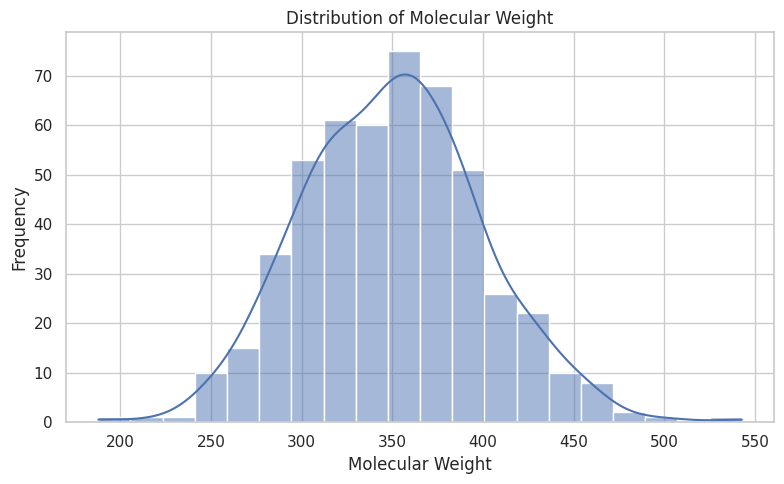

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Molecular_Weight",
    bins=20,
    kde=True
)

plt.title("Distribution of Molecular Weight")
plt.xlabel("Molecular Weight")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation

The Molecular Weight distribution shows how the molecular sizes are distributed across the synthetic compound dataset.

The histogram provides an overview of the central region, spread, and possible extreme values of Molecular Weight. The density curve provides an additional view of the overall distribution.

## 7. Distribution of LogP

LogP is examined to understand the distribution of the compounds with respect to the simulated lipophilicity-related descriptor.

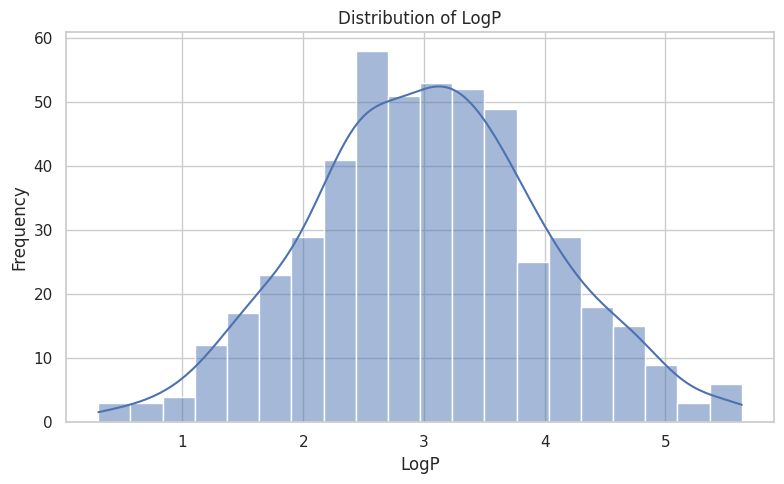

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="LogP",
    bins=20,
    kde=True
)

plt.title("Distribution of LogP")
plt.xlabel("LogP")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation

The LogP distribution shows the range and spread of the simulated LogP values in the dataset.

The distribution can be used to understand the chemical-property space represented by the synthetic compounds.

## 8. Distribution of HBA

Hydrogen Bond Acceptors (HBA) are examined to understand their distribution among the synthetic compounds.

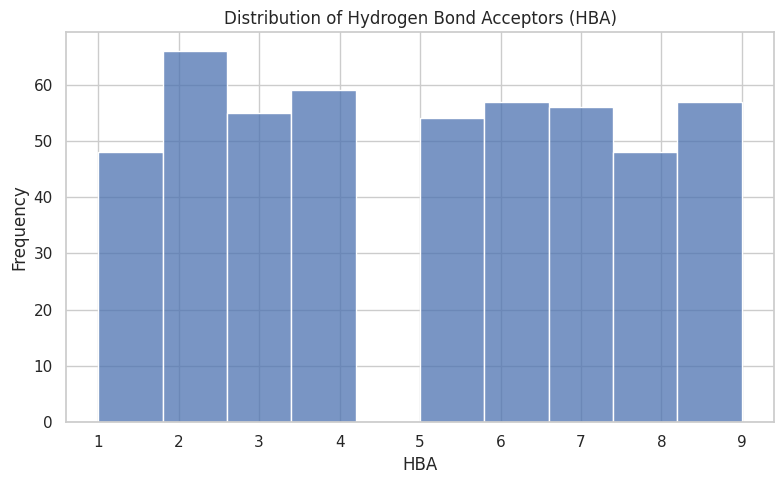

In [24]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="HBA",
    bins=10,
    kde=False
)

plt.title("Distribution of Hydrogen Bond Acceptors (HBA)")
plt.xlabel("HBA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 9. Distribution of HBD

Hydrogen Bond Donors (HBD) are examined to understand their distribution across the dataset.

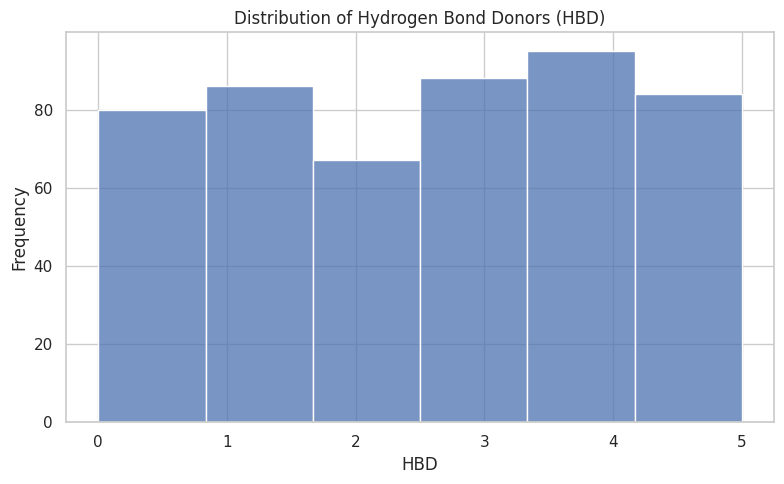

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="HBD",
    bins=6,
    kde=False
)

plt.title("Distribution of Hydrogen Bond Donors (HBD)")
plt.xlabel("HBD")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 10. Distribution of TPSA

The distribution of Topological Polar Surface Area (TPSA) is examined to understand the spread of this molecular descriptor.

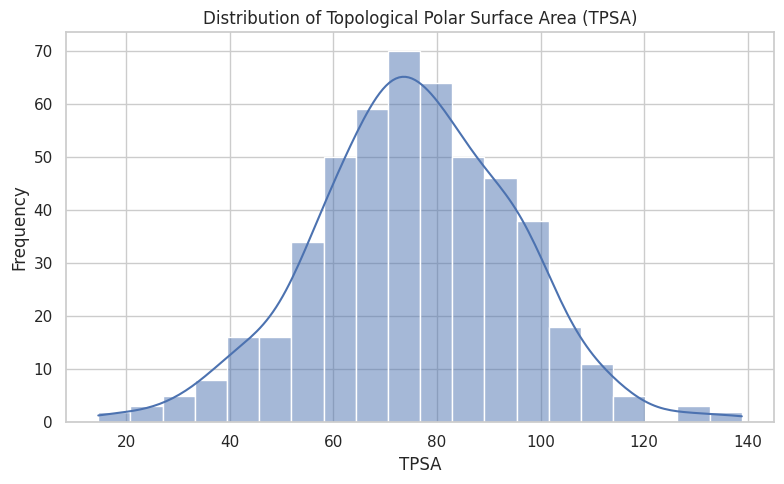

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="TPSA",
    bins=20,
    kde=True
)

plt.title("Distribution of Topological Polar Surface Area (TPSA)")
plt.xlabel("TPSA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 11. Distribution of Rotatable Bonds

Rotatable Bonds are examined to understand the flexibility-related descriptor distribution within the synthetic compound dataset.

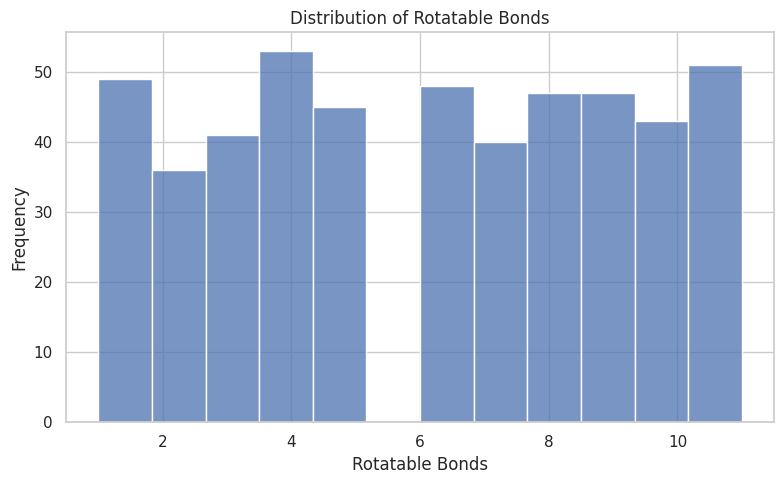

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Rotatable_Bonds",
    bins=12,
    kde=False
)

plt.title("Distribution of Rotatable Bonds")
plt.xlabel("Rotatable Bonds")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 12. Bioactivity Class Distribution

The distribution of Active and Inactive compounds is visualized to understand the composition of the target variable.

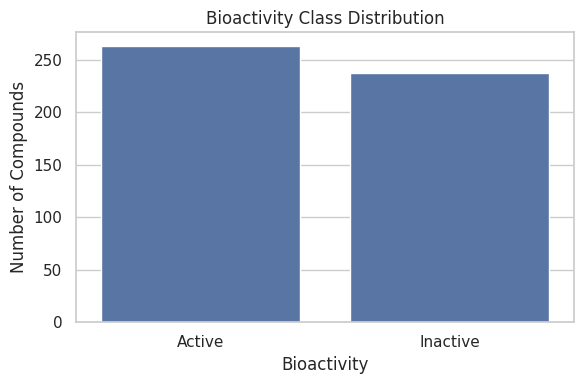

In [28]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Bioactivity"
)

plt.title("Bioactivity Class Distribution")
plt.xlabel("Bioactivity")
plt.ylabel("Number of Compounds")

plt.tight_layout()
plt.show()

### Interpretation

The bioactivity distribution provides an overview of the number of compounds belonging to each bioactivity class.

This is important for understanding the target variable before applying supervised machine-learning methods in the subsequent predictive-modeling stage.

## 13. Correlation Analysis

Correlation analysis is performed to examine relationships between the numerical molecular descriptors.

The Pearson correlation coefficient is used to quantify the strength and direction of linear relationships between pairs of descriptors.

In [29]:
# Calculate the correlation matrix

correlation_matrix = df[descriptors].corr()

correlation_matrix

,Molecular_Weight,LogP,HBA,HBD,TPSA,Rotatable_Bonds
Molecular_Weight,1.000000,-0.075671,-0.020575,-0.076313,-0.025307,0.010702
LogP,-0.075671,1.000000,0.009935,-0.034738,-0.004411,-0.011207
HBA,-0.020575,0.009935,1.000000,0.001929,-0.026438,-0.051923
HBD,-0.076313,-0.034738,0.001929,1.000000,-0.046462,0.052882
TPSA,-0.025307,-0.004411,-0.026438,-0.046462,1.000000,0.043490
Rotatable_Bonds,0.010702,-0.011207,-0.051923,0.052882,0.043490,1.000000


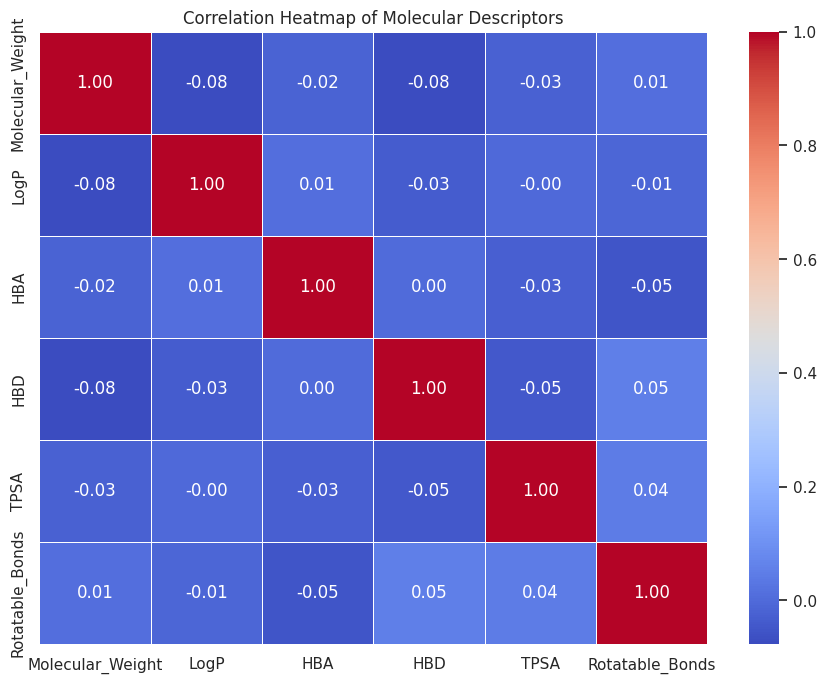

In [30]:
# Visualize the correlation matrix

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Molecular Descriptors")

plt.tight_layout()
plt.show()

### Interpretation

The correlation heatmap provides a visual summary of the relationships among the molecular descriptors.

Positive correlation indicates that two descriptors tend to increase together, while negative correlation indicates an inverse relationship. Values closer to zero indicate weaker linear relationships.

The heatmap can also help identify descriptors that may contain overlapping information before predictive modeling.

## 14. Outlier Analysis

Box plots are used to visually inspect the distributions of molecular descriptors and identify potential extreme observations.

Potential outliers identified visually should be interpreted carefully because the dataset is synthetic.

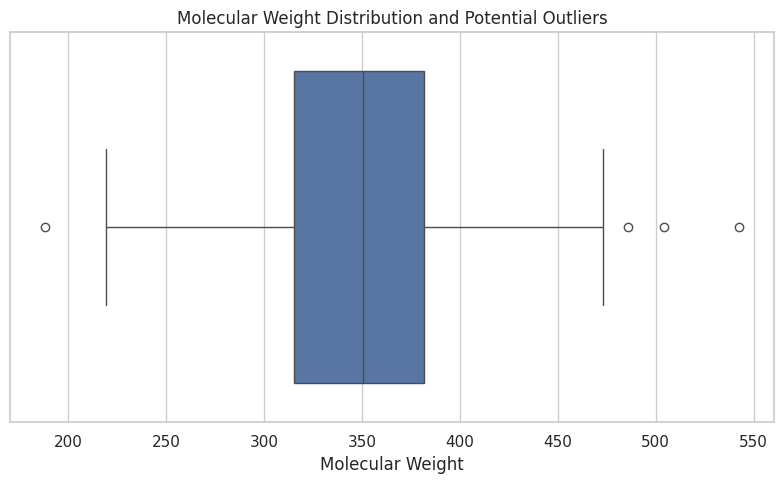

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["Molecular_Weight"]
)

plt.title("Molecular Weight Distribution and Potential Outliers")
plt.xlabel("Molecular Weight")

plt.tight_layout()
plt.show()

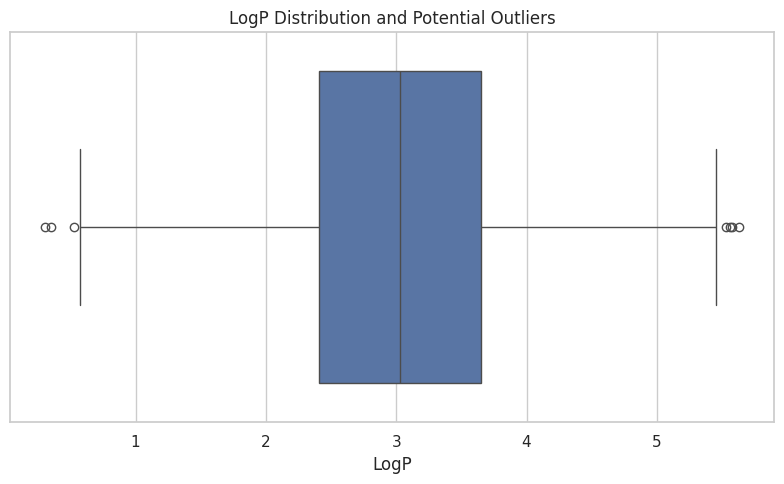

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["LogP"]
)

plt.title("LogP Distribution and Potential Outliers")
plt.xlabel("LogP")

plt.tight_layout()
plt.show()

## 15. Molecular Weight vs LogP

A scatter plot is used to examine the relationship between Molecular Weight and LogP while distinguishing the Bioactivity classes.

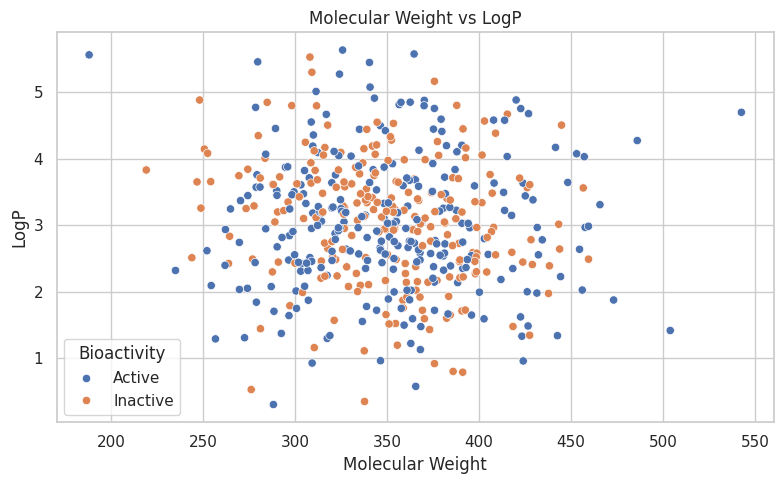

In [33]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Molecular_Weight",
    y="LogP",
    hue="Bioactivity"
)

plt.title("Molecular Weight vs LogP")
plt.xlabel("Molecular Weight")
plt.ylabel("LogP")

plt.tight_layout()
plt.show()

### Interpretation

The scatter plot provides a visual representation of the relationship between Molecular Weight and LogP.

Color-coding by Bioactivity allows the distribution of Active and Inactive compounds to be compared across this two-dimensional chemical-property space.

## 16. Pairwise Relationship Analysis

Pairwise relationships between the molecular descriptors are examined to obtain a broader view of the chemical-property space.

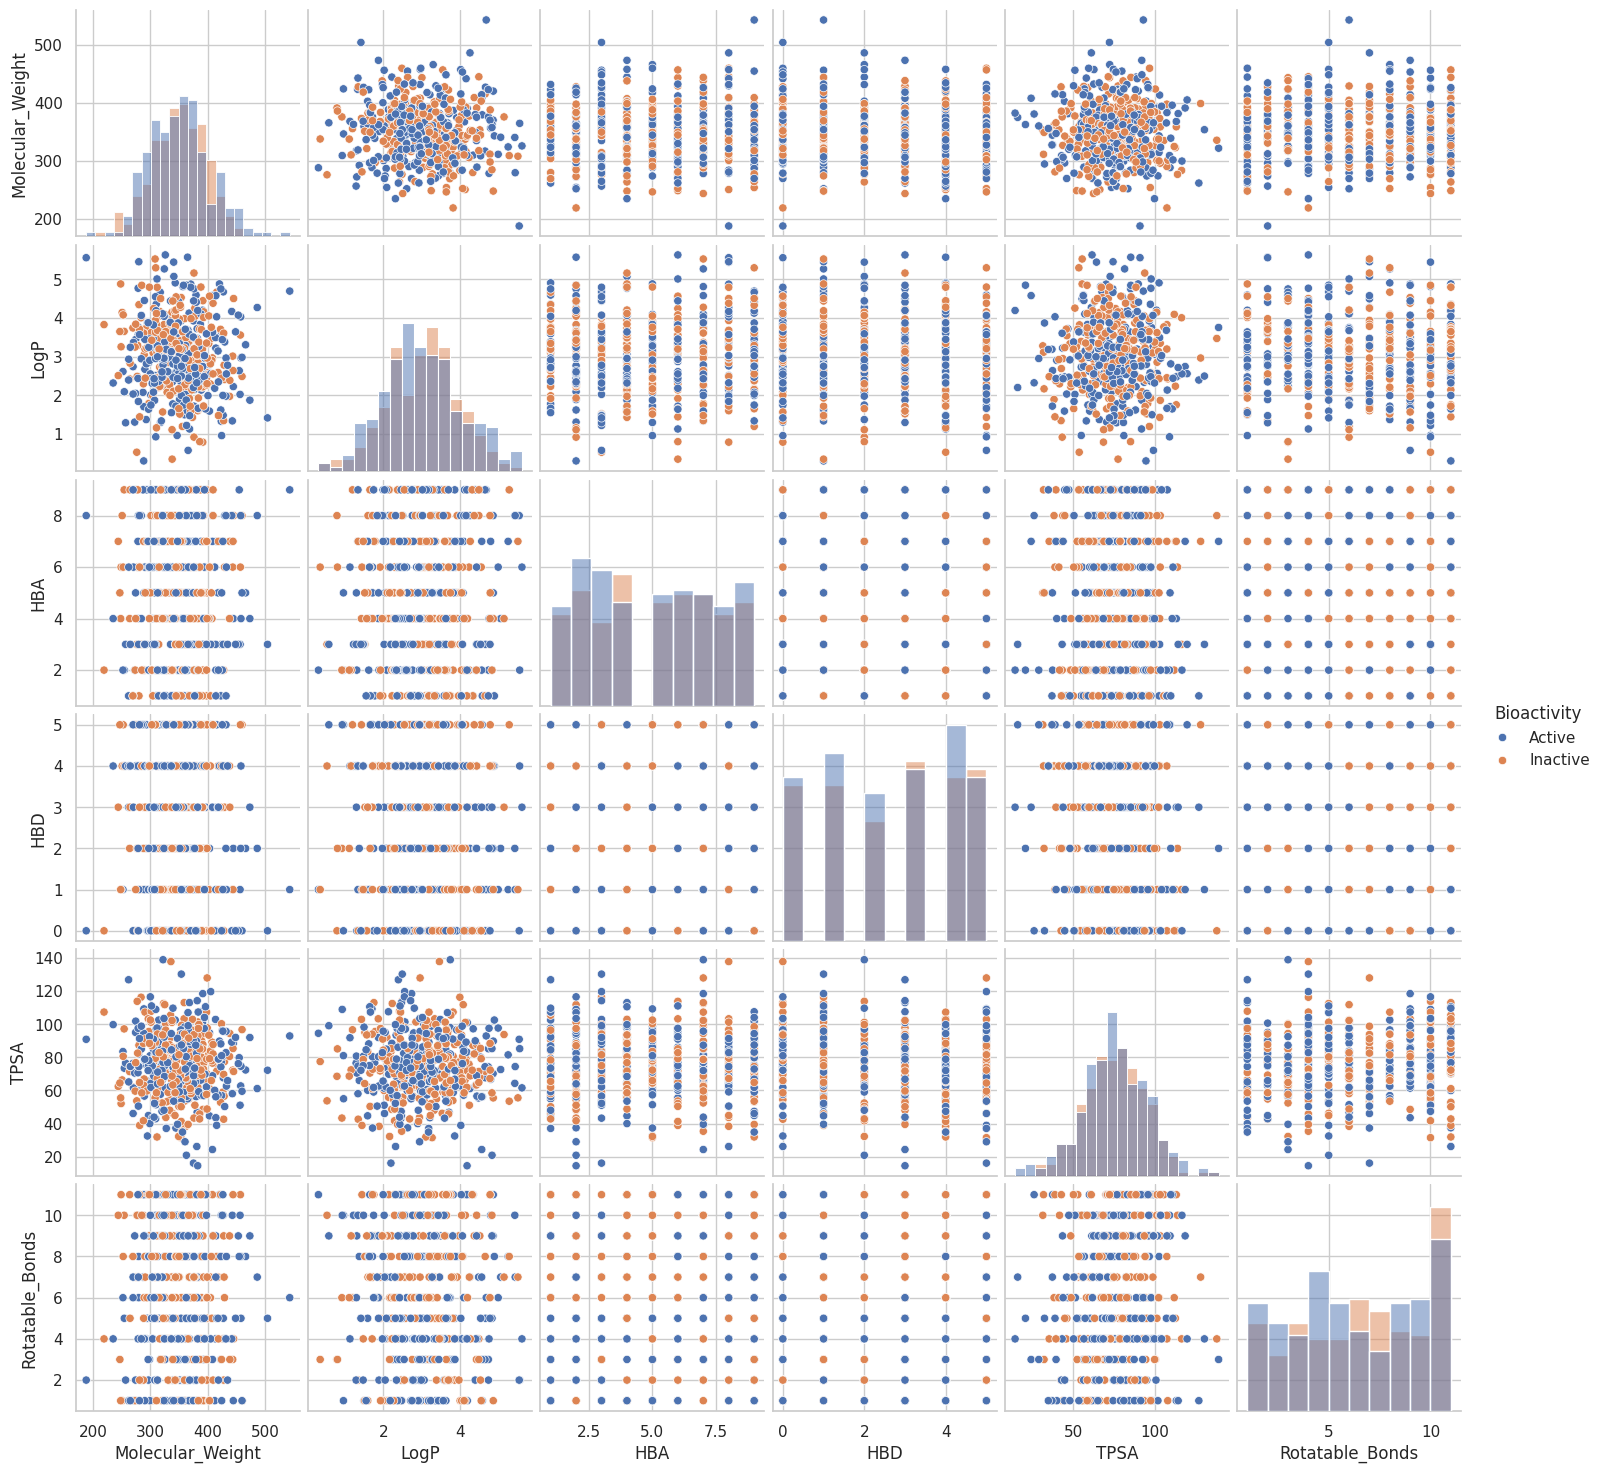

In [34]:
sns.pairplot(
    df,
    vars=descriptors,
    hue="Bioactivity",
    diag_kind="hist"
)

plt.show()

### Interpretation

The pairwise plots provide a comprehensive visual overview of relationships between the molecular descriptors.

The diagonal distributions show the individual descriptor distributions, while the off-diagonal plots show pairwise relationships. Bioactivity-based coloring allows differences in the distribution of Active and Inactive compounds to be visually examined.

## 17. Summary of Exploratory Analysis

The Week 2 exploratory analysis examined a synthetic dataset containing 500 chemical compounds and molecular descriptors including Molecular Weight, LogP, HBA, HBD, TPSA, and Rotatable Bonds.

Data-quality checks were performed to identify missing values and duplicate records. Descriptive statistics were then used to summarize the molecular descriptors.

Multiple visualizations were generated to investigate descriptor distributions, bioactivity class composition, potential outliers, and relationships between molecular properties.

Correlation analysis provided an overview of linear relationships among the molecular descriptors, while scatter and pairwise plots helped visualize the chemical-property space and compare Active and Inactive compounds.

The findings from this exploratory stage provide a foundation for the predictive modeling performed in Week 3 and the detailed data visualization and interpretation performed in Week 4.

## Conclusion

The Week 2 analysis established a structured understanding of the synthetic chemical-compound dataset through data inspection, quality checking, descriptive statistics, and exploratory visualization.

The analysis confirmed the structure of the dataset and examined the major molecular descriptors and bioactivity classes.

The resulting exploratory insights provide a foundation for subsequent machine-learning analysis and visualization-based interpretation in the later stages of the project.